In [8]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components
from scipy.special import logsumexp
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# --- repository paths -------------------------------------------------------
# `pip install -e .` from the repository root makes this import work anywhere;
# the fallback covers a plain `jupyter lab` started without installing.
try:
    from scisoc.config import paths
except ModuleNotFoundError:
    _here = Path.cwd().resolve()
    _root = next(p for p in (_here, *_here.parents) if (p / "src" / "scisoc").is_dir())
    sys.path.insert(0, str(_root / "src"))
    from scisoc.config import paths

from scisoc.io import load_node_info

paths.ensure()
print(paths.describe())

# The raw subject tables live outside the repository (external drive).
# Point at them with SCISOC_RAW in the environment or in <repo>/.env, e.g.
#     SCISOC_RAW=/Volumes/My Passport_2/Science-Society/data/processed
NEWS_PATH    = paths.raw_subjects("news")     # news_subject_by_year.pkl
PAPER_PATH   = paths.raw_subjects("paper")    # paper_subject_by_year.pkl

NETWORKS_DIR = paths.networks                 # networks/<source>/adj_<year>.npz + node_info.pkl
BACKBONE_DIR = paths.backbone                 # backbone/<source>_<year>_backbone.parquet
EMB_DIR      = paths.embeddings               # <source>_E.npz from src/dysat/train.py
CP_DIR       = paths.cp_results
PLOT_DIR     = paths.figures

SOURCES = ["news", "paper"]
ALPHAS = [0.01, 0.05, 0.1, 0.2]


root         /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc
raw (input)  /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/data/raw
networks     /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/data/processed/networks
backbone     /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/data/processed/backbone
embeddings   /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/data/processed/embeddings
cp_results   /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/results/cp_results
figures      /Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc/results/figures


In [4]:
info = {s: load_node_info(s, NETWORKS_DIR) for s in SOURCES}

### Backbone

In [2]:
def disparity_alpha(W):
    W = W.tocsr()
    s = np.asarray(W.sum(axis=1)).ravel()
    k = np.diff(W.indptr)

    coo = W.tocoo()
    keep = coo.row < coo.col
    i, j, w = coo.row[keep], coo.col[keep], coo.data[keep]

    def alpha(node, w_):
        kk = k[node]
        p = np.divide(w_, s[node], out=np.zeros_like(w_), where=s[node] > 0)
        a = np.power(1.0 - p, np.maximum(kk - 1, 0))
        return np.where(kk > 1, a, 1.0)

    a_i, a_j = alpha(i, w), alpha(j, w)
    return pd.DataFrame({"i": i, "j": j, "w": w,
                         "alpha_min": np.minimum(a_i, a_j)})

def rca_score(W):
    W = W.tocsr()
    s = np.asarray(W.sum(axis=1)).ravel()
    total = s.sum() / 2.0

    coo = W.tocoo()
    keep = coo.row < coo.col
    i, j, w = coo.row[keep], coo.col[keep], coo.data[keep]

    denom = s[i] * s[j]
    rca = np.divide(w * total, denom, out=np.zeros_like(w), where=denom > 0)
    return pd.DataFrame({"i": i, "j": j, "w": w, "rca": rca})

def extract_backbone(W, density_k=3.0, method="disparity", scored=None):
    """`scored` accepts a precomputed score table so it is not recomputed."""
    if method == "disparity":
        df = disparity_alpha(W) if scored is None else scored
        sort_cols, asc = ["alpha_min", "w"], [True, False]
    elif method == "rca":
        df = rca_score(W) if scored is None else scored
        sort_cols, asc = ["rca", "w"], [False, False]
    else:
        raise ValueError(method)

    if df.empty:
        return df.assign(mst_only=pd.Series(dtype=int))

    n_active = int((np.asarray(W.sum(axis=1)).ravel() > 0).sum())
    n_keep = min(int(round(density_k * n_active)), len(df))

    df = df.sort_values(sort_cols, ascending=asc, kind="mergesort").reset_index(drop=True)
    cut = df.iloc[:n_keep].copy()
    cut["mst_only"] = 0

    neg = csr_matrix((-W.data, W.indices, W.indptr), shape=W.shape)
    mst = minimum_spanning_tree(neg).tocoo()
    mst_pairs = {(min(a, b), max(a, b)) for a, b in zip(mst.row, mst.col)}
    have = set(zip(cut.i.to_numpy(), cut.j.to_numpy()))
    add = mst_pairs - have

    if add:
        rest = df.iloc[n_keep:]
        idx = pd.MultiIndex.from_arrays([rest.i, rest.j])
        extra = rest[idx.isin(list(add))].copy()
        extra["mst_only"] = 1
        cut = pd.concat([cut, extra], ignore_index=True)
    return cut

In [4]:
BACKBONE_DIR.mkdir(parents=True, exist_ok=True)
for a in ALPHAS:
    (BACKBONE_DIR / f"alpha{a}").mkdir(parents=True, exist_ok=True)

rows = []
for source in SOURCES:
    info_s = info[source]
    prev = {"disparity": None, "rca": None}

    for year in tqdm(info_s["years"], desc=source):
        W = load_npz(NETWORKS_DIR / source / f"adj_{year}.npz").tocsr()
        deg = np.diff(W.indptr).astype(float)
        s_orig = np.asarray(W.sum(axis=1)).ravel()
        act = s_orig > 0
        total_w = W.data.sum() / 2

        da = disparity_alpha(W)

        r = {"source": source, "year": int(year),
             "N_t": int(act.sum()), "E_t": W.nnz // 2}
        cur = {}

        bb = {}
        for m in ["disparity", "rca"]:
            d = extract_backbone(W, 3.0, m, scored=da if m == "disparity" else None)
            bb[m] = d
            sel = d[d.mst_only == 0]
            cur[m] = set(zip(d.i.to_numpy(), d.j.to_numpy()))

            if m == "disparity":
                d.to_parquet(BACKBONE_DIR / f"{source}_{year}_backbone.parquet")

            # does the backbone keep the original ranking of concepts?
            s_bb = np.zeros(W.shape[0])
            np.add.at(s_bb, d.i.to_numpy(), d.w.to_numpy())
            np.add.at(s_bb, d.j.to_numpy(), d.w.to_numpy())
            r[f"{m}_strength_corr"] = float(spearmanr(s_orig[act], s_bb[act]).correlation)

            # is the same structure picked up from one year to the next?
            r[f"{m}_year_jac"] = (len(cur[m] & prev[m]) / len(cur[m] | prev[m])
                                  if prev[m] else np.nan)

            r[f"{m}_wret"] = float(d.w.sum() / total_w)
            r[f"{m}_endpoint_deg"] = float((deg[sel.i] + deg[sel.j]).mean() / 2)
            r[f"{m}_E_bb"] = len(d)
            r[f"{m}_mean_degree"] = 2 * len(d) / len(np.unique(
                np.concatenate([d.i.to_numpy(), d.j.to_numpy()])))

        # the alpha the density rule implies, read off the backbone built above
        r["implied_alpha"] = float(bb["disparity"].query("mst_only == 0").alpha_min.max())

        for a in ALPHAS:
            sig = da[da.alpha_min < a]
            sig.to_parquet(BACKBONE_DIR / f"alpha{a}" / f"{source}_{year}_backbone.parquet")

            if len(sig):
                nd = np.unique(np.concatenate([sig.i.to_numpy(), sig.j.to_numpy()]))
                sub = csr_matrix((np.ones(len(sig)), (sig.i, sig.j)), shape=W.shape)
                nc, lab = connected_components(sub + sub.T, directed=False)
                sizes = np.bincount(lab)
                sizes = sizes[sizes > 1]

                r[f"a{a}_deg"] = 2 * len(sig) / len(nd)
                r[f"a{a}_cov"] = len(nd) / int(act.sum())
                r[f"a{a}_wret"] = float(sig.w.sum() / total_w)
                r[f"a{a}_giant"] = float(sizes.max() / sizes.sum()) if len(sizes) else 0.0
            else:
                r[f"a{a}_deg"] = r[f"a{a}_cov"] = 0.0
                r[f"a{a}_wret"] = r[f"a{a}_giant"] = 0.0

        r["jaccard"] = len(cur["disparity"] & cur["rca"]) / len(cur["disparity"] | cur["rca"])
        prev = cur
        rows.append(r)

bb_cmp = pd.DataFrame(rows)
bb_cmp.to_csv(BACKBONE_DIR / "filter_comparison.csv", index=False)
bb_cmp.head()

news:   0%|          | 0/34 [00:00<?, ?it/s]

paper:   0%|          | 0/34 [00:00<?, ?it/s]

,source,year,N_t,E_t,disparity_strength_corr,disparity_year_jac,disparity_wret,disparity_endpoint_deg,disparity_E_bb,disparity_mean_degree,...,a0.05_giant,a0.1_deg,a0.1_cov,a0.1_wret,a0.1_giant,a0.2_deg,a0.2_cov,a0.2_wret,a0.2_giant,jaccard
0,news,1990,2434,43851,0.858670,NaN,0.581188,308.656327,8450,6.943303,...,0.953992,8.334372,0.395645,0.457047,0.973001,10.461318,0.573541,0.560162,0.983524,0.205649
1,news,1991,1664,15338,0.873587,0.105604,0.710997,120.447015,5736,6.894231,...,0.960526,4.686456,0.323918,0.404472,0.964750,5.683832,0.501803,0.515777,0.978443,0.312542
2,news,1992,2392,39561,0.862193,0.104775,0.630660,298.565496,8330,6.964883,...,0.955651,8.008639,0.387124,0.501690,0.961123,9.983333,0.551839,0.596261,0.980303,0.208951
3,news,1993,2437,38124,0.860606,0.199657,0.613321,265.144850,8440,6.926549,...,0.965847,7.005128,0.400082,0.458866,0.961026,8.861190,0.579401,0.560685,0.987252,0.223786
4,news,1994,2642,46871,0.875032,0.206826,0.614884,314.559992,9135,6.915216,...,0.960419,7.909010,0.424300,0.498712,0.970562,10.244558,0.591219,0.598198,0.989117,0.209804


In [5]:
bb_cmp.groupby("source").agg(
    jaccard=("jaccard", "median"),
    disp_strength=("disparity_strength_corr", "median"),
    rca_strength=("rca_strength_corr", "median"),
    disparity_year_jac=("disparity_year_jac", "median"),
    rca_year_jac=("rca_year_jac", "median"),
    disp_wret=("disparity_wret", "median"),
    rca_wret=("rca_wret", "median"),
    mean_degree=("disparity_mean_degree", "median"),
).round(3)

,jaccard,disp_strength,rca_strength,disparity_year_jac,rca_year_jac,disp_wret,rca_wret,mean_degree
source,,,,,,,,
news,0.188,0.906,0.876,0.304,0.070,0.582,0.231,6.977
paper,0.164,0.948,0.937,0.510,0.125,0.541,0.152,7.090


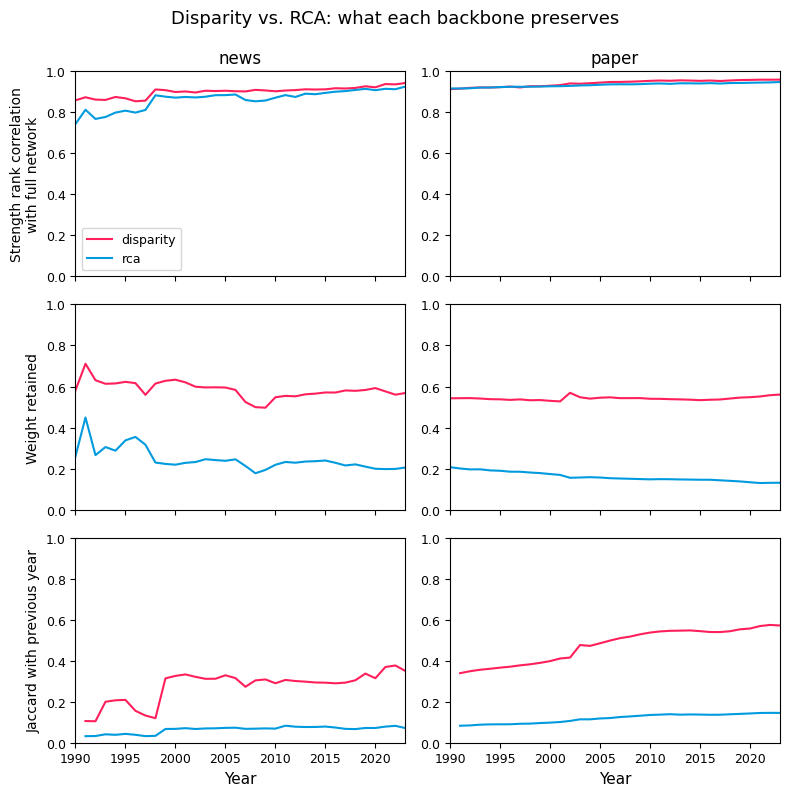

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=True)
C = {"disparity": "#FF1F5B", "rca": "#009ADE"}

for col, s in enumerate(SOURCES):
    d = bb_cmp[bb_cmp.source == s]

    # does it preserve the original hierarchy?
    ax = axes[0, col]
    for m in C:
        ax.plot(d.year, d[f"{m}_strength_corr"], color=C[m], lw=1.5, label=m)
    ax.set_ylim(0, 1)
    ax.set_title(s, fontsize=12)
    if col == 0:
        ax.set_ylabel("Strength rank correlation\nwith full network", fontsize=10)
        ax.legend(fontsize=9)

    # how much of the original weight survives?
    ax = axes[1, col]
    for m in C:
        ax.plot(d.year, d[f"{m}_wret"], color=C[m], lw=1.5)
    ax.set_ylim(0, 1)
    if col == 0:
        ax.set_ylabel("Weight retained", fontsize=10)

    # is the structure stable across years?
    ax = axes[2, col]
    for m in C:
        ax.plot(d.year, d[f"{m}_year_jac"], color=C[m], lw=1.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Year", fontsize=11)
    if col == 0:
        ax.set_ylabel("Jaccard with previous year", fontsize=10)

for ax in axes.flat:
    ax.set_xlim(1990, 2023)
    ax.tick_params(labelsize=9)

fig.suptitle("Disparity vs. RCA: what each backbone preserves", fontsize=13, y=0.99)
plt.tight_layout()
plt.savefig(PLOT_DIR / "backbone_disparity_vs_rca.png", dpi=300, bbox_inches="tight")
plt.show()

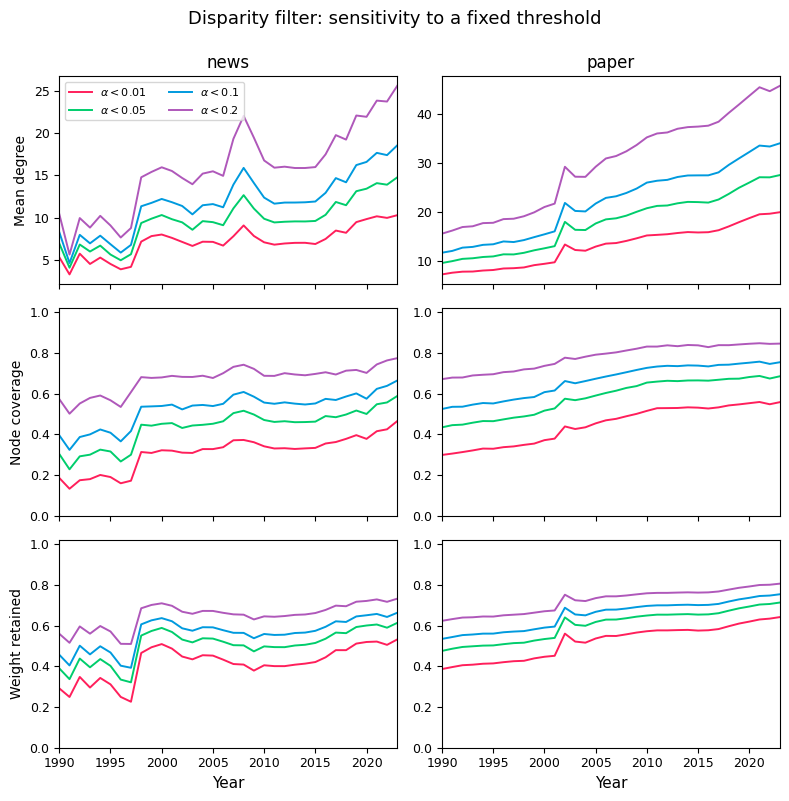

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=True)
AC = {0.01: "#FF1F5B", 0.05: "#00CD6C", 0.1: "#009ADE", 0.2: "#AF58BA"}
PANELS = [("deg", "Mean degree"),
          ("cov", "Node coverage"),
          ("wret", "Weight retained")]

for col, s in enumerate(SOURCES):
    d = bb_cmp[bb_cmp.source == s]
    for row, (key, ylab) in enumerate(PANELS):
        ax = axes[row, col]
        for a, c in AC.items():
            ax.plot(d.year, d[f"a{a}_{key}"], color=c, lw=1.4,
                    label=rf"$\alpha<{a}$")
        if key != "deg":
            ax.set_ylim(0, 1.02)
        if row == 0:
            ax.set_title(s, fontsize=12)
            if col == 0:
                ax.legend(fontsize=8, ncol=2)
        if col == 0:
            ax.set_ylabel(ylab, fontsize=10)
        if row == len(PANELS) - 1:
            ax.set_xlabel("Year", fontsize=11)
        ax.set_xlim(1990, 2023)
        ax.tick_params(labelsize=9)

fig.suptitle("Disparity filter: sensitivity to a fixed threshold", fontsize=13, y=0.995)
plt.tight_layout()
plt.savefig(PLOT_DIR / "backbone_alpha_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### Persistent path

In [ ]:
def edge_presence(source, info, bb_dir):
    """{(i, j): bool[T]} -- for every edge that was ever in the backbone, the years it was."""
    years = list(info["years"])
    present = {}
    for t, year in enumerate(years):
        bb = pd.read_parquet(Path(bb_dir) / f"{source}_{year}_backbone.parquet")
        for i, j in zip(bb.i.to_numpy(), bb.j.to_numpy()):
            present.setdefault((int(i), int(j)), np.zeros(len(years), bool))[t] = True
    return present


def longest_run(mask):
    """(length, start index) of the longest run of consecutive True values."""
    best = run = best_start = start = 0
    for t, v in enumerate(mask):
        if v:
            if run == 0:
                start = t
            run += 1
            if run > best:
                best, best_start = run, start
        else:
            run = 0
    return best, best_start


def persistent_edges(present, years, min_years=20):
    """
    Edges in the backbone for at least min_years CONSECUTIVE years.

    Necessary for an edge to lie on a persistent path, not sufficient: the path's
    edges must also share one window (persistent_paths checks that).
    """
    rows = []
    for (i, j), m in present.items():
        run, s = longest_run(m)
        if run >= min_years:
            rows.append((i, j, run, int(years[s]), int(years[s + run - 1])))
    return pd.DataFrame(rows, columns=["i", "j", "run", "start", "end"])


def persistent_paths(present, pers_edges, years, length=8, min_years=20, seed=0):
    """
    Paths of `length` concepts whose edges are ALL in the backbone at the same time
    for at least min_years consecutive years.

    A random walk from every node in random order. A candidate edge is accepted only
    if AND-ing its presence mask with the path's so far still leaves a run of at
    least min_years. So robot-control (1990-2010) and control-power (2003-2023) do
    not chain: together they hold for 8 years, not 20.

    Each path carries its window (start, end, run). Inside the window every edge is
    in the backbone, hence every node is active, so the whole chain can be scored in
    every year of the window. One path per start node; deduplicated on the node set.
    """
    rng = np.random.default_rng(seed)
    adj = {}
    for i, j in zip(pers_edges.i, pers_edges.j):
        adj.setdefault(int(i), set()).add(int(j))
        adj.setdefault(int(j), set()).add(int(i))

    def mask_of(a, b):
        return present[(min(a, b), max(a, b))]

    paths, seen = [], set()
    for s in rng.permutation(list(adj)):
        path, mask = [int(s)], np.ones(len(years), bool)
        while len(path) < length:
            cands = [c for c in adj[path[-1]] if c not in path]
            rng.shuffle(cands)
            for c in cands:
                m = mask & mask_of(path[-1], c)
                if longest_run(m)[0] >= min_years:
                    path.append(c)
                    mask = m
                    break
            else:
                break
        if len(path) < length:
            continue
        key = tuple(sorted(path))
        if key in seen:
            continue
        seen.add(key)
        run, st = longest_run(mask)
        paths.append({"nodes": path, "start": int(years[st]),
                      "end": int(years[st + run - 1]), "run": int(run)})
    return paths


In [ ]:
MIN_YEARS, PATH_LEN = 20, 8

present = {s: edge_presence(s, info[s], BACKBONE_DIR) for s in SOURCES}
pe = {s: persistent_edges(present[s], info[s]["years"], MIN_YEARS) for s in SOURCES}
paths_seq = {s: persistent_paths(present[s], pe[s], info[s]["years"], PATH_LEN, MIN_YEARS)
             for s in SOURCES}

for s in SOURCES:
    P = paths_seq[s]
    nodes = {n for p in P for n in p["nodes"]}
    line = f"{s}: {len(pe[s]):,} persistent edges | {len(P):,} paths | {len(nodes):,} unique nodes"
    if P:
        runs = np.array([p["run"] for p in P]); starts = np.array([p["start"] for p in P])
        line += (f" | window {int(np.median(runs))} yrs median (min {runs.min()}, max {runs.max()})"
                 f" | starts {starts.min()}-{starts.max()}")
    print(line)

with open(BACKBONE_DIR / "persistent_paths.pkl", "wb") as f:
    pickle.dump({"paths": paths_seq, "pers_edges": pe,
                 "min_years": MIN_YEARS, "length": PATH_LEN}, f)


In [ ]:
present_a, pe_a, edge_sets = {}, {}, {}
for source in SOURCES:
    for a in ALPHAS:
        present_a[(source, a)] = edge_presence(source, info[source], BACKBONE_DIR / f"alpha{a}")
        pe_a[(source, a)] = persistent_edges(present_a[(source, a)], info[source]["years"], MIN_YEARS)
        edge_sets[(source, a)] = set(zip(pe_a[(source, a)].i, pe_a[(source, a)].j))
        print(f"{source} alpha<{a}: {len(pe_a[(source, a)]):,} persistent edges")


In [ ]:
pers_alpha = pd.DataFrame([
    {"source": s, "alpha": a, "n_persistent": len(edge_sets[(s, a)])}
    for s in SOURCES for a in ALPHAS
])

# how much does the persistent set change with the threshold?
for s in SOURCES:
    base = edge_sets[(s, 0.05)]
    for a in ALPHAS:
        e = edge_sets[(s, a)]
        pers_alpha.loc[(pers_alpha.source == s) & (pers_alpha.alpha == a),
                       "jaccard_vs_005"] = (len(base & e) / len(base | e)
                                            if (base | e) else np.nan)

path_alpha, path_sets = [], {}
for source in SOURCES:
    for a in ALPHAS:
        p = persistent_paths(present_a[(source, a)], pe_a[(source, a)], info[source]["years"],
                             PATH_LEN, MIN_YEARS, seed=0)
        path_sets[(source, a)] = {n for x in p for n in x["nodes"]}
        path_alpha.append({"source": source, "alpha": a,
                           "n_paths": len(p), "n_nodes": len(path_sets[(source, a)])})

path_alpha = pd.DataFrame(path_alpha)
for s in SOURCES:
    base = path_sets[(s, 0.05)]
    for a in ALPHAS:
        cur = path_sets[(s, a)]
        path_alpha.loc[(path_alpha.source == s) & (path_alpha.alpha == a),
                       "node_jaccard_vs_005"] = (len(base & cur) / len(base | cur)
                                                 if (base | cur) else np.nan)

pers_alpha.merge(path_alpha, on=["source", "alpha"]).round(3)

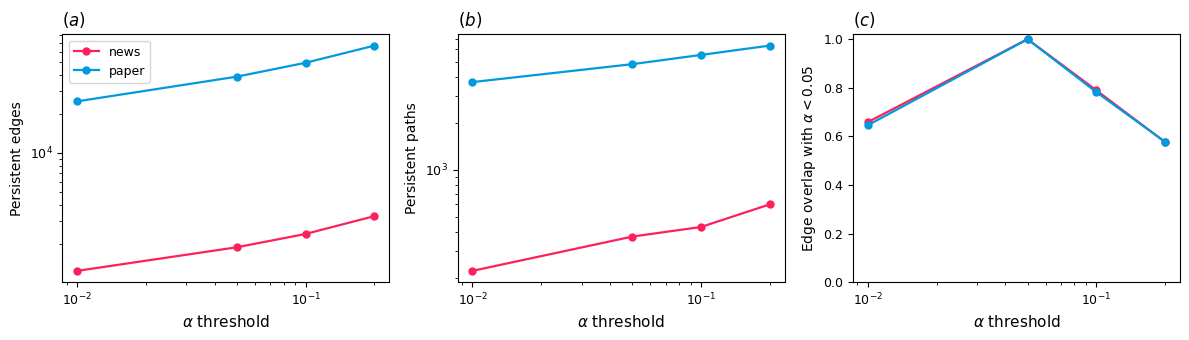

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
C = {"news": "#FF1F5B", "paper": "#009ADE"}

ax = axes[0]
for s in SOURCES:
    d = pers_alpha[pers_alpha.source == s]
    ax.plot(d.alpha, d.n_persistent, color=C[s], lw=1.6, marker="o", ms=5, label=s)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylabel("Persistent edges", fontsize=10)
ax.legend(fontsize=9)
ax.set_title("$(a)$", loc="left")

ax = axes[1]
for s in SOURCES:
    d = path_alpha[path_alpha.source == s]
    ax.plot(d.alpha, d.n_paths, color=C[s], lw=1.6, marker="o", ms=5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylabel("Persistent paths", fontsize=10)
ax.set_title("$(b)$", loc="left")

ax = axes[2]
for s in SOURCES:
    d = pers_alpha[pers_alpha.source == s]
    ax.plot(d.alpha, d.jaccard_vs_005, color=C[s], lw=1.6, marker="o", ms=5)
ax.set_xscale("log"); ax.set_ylim(0, 1.02)
ax.set_ylabel(r"Edge overlap with $\alpha<0.05$", fontsize=10)
ax.set_title("$(c)$", loc="left")

for ax in axes:
    ax.set_xlabel(r"$\alpha$ threshold", fontsize=11)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / "persistent_alpha_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### Perplexity

In [ ]:
# Resume here: everything the perplexity cells need, read back from disk.
# Cells 1 and 10 produce the same objects when the notebook is run in order.
info = {s: load_node_info(s, NETWORKS_DIR) for s in SOURCES}

with open(BACKBONE_DIR / "persistent_paths.pkl", "rb") as f:
    _saved = pickle.load(f)
paths_seq = _saved["paths"]          # {source: [{"nodes": [...], "start": y, "end": y, "run": L}, ...]}
MIN_YEARS, PATH_LEN = _saved["min_years"], _saved["length"]
print({s: f"{len(p):,} paths" for s, p in paths_seq.items()},
      f"| min_years={MIN_YEARS} length={PATH_LEN}")


In [ ]:
def log_cond_prob(Za, v):
    """
    log p_t(u | v) for every active concept u -- the model's trained conditional.

    Exactly the quantity the training loss normalizes (models.py _loss): softmax over
    the concepts active in year t of <E_v, E_u>, with u = v masked out.
    Za is E[:, t, :] restricted to the active concepts; v is a local index into Za.
    """
    s = Za @ Za[v]
    s[v] = -np.inf
    return s - logsumexp(s)                       # log-softmax: log p(u | v)


def log_cond_prob_given_set(Za, ctx):
    """
    log p_t(u | ctx) for a SET of conditioning concepts.

    The model was trained with one condition at a time, so a set needs a combination
    rule. We take the geometric mean of the pairwise conditionals and renormalize:

        p(A | B, C, D)  ∝  [ p(A|B) · p(A|C) · p(A|D) ]^(1/3)

    The 1/|ctx| exponent is deliberate: it keeps the score independent of the context
    size, so paths of different lengths (K = 6 vs K = 8) stay comparable. A plain
    product would sharpen with every extra condition and confound length with fit.
    Concepts in ctx are excluded as candidates, since each p(·|v) masks v itself.
    """
    lp = np.mean([log_cond_prob(Za, v) for v in ctx], axis=0)
    return lp - logsumexp(lp)


def path_perplexity(seq_paths, Z_t, active_idx, year, pairs=False):
    """
    Pseudo-perplexity of each path under the model in one year: mask one concept at
    a time and score it with p(A | rest of the path); exp of the mean negative
    log-probability over the masked positions. n_active is the candidate count, so
    ppl / n_active = 1 is chance.

    Only paths whose window contains `year` are scored. Inside the window every edge
    of the path is in that year's backbone, so every concept is active and the whole
    chain is scored -- the object measured is the same in every year of the window.
    rel_year counts from the window's first year (1) so paths with different windows
    can be aligned.

    pairs=True adds ppl_pair, a diagnostic: p(u | v) on the path's adjacent pairs in
    both directions, i.e. the trained distribution with no combination rule. It scores
    links one at a time, never the chain, and the backbone selected those links for
    being strong -- a sanity anchor against the model's held-out perplexity, not a
    measure of the research question. Kept out of the main table.
    """
    pos = {int(n): k for k, n in enumerate(active_idx)}
    Za = Z_t[active_idx].astype(np.float64)

    rows = []
    for p in seq_paths:
        if not (p["start"] <= year <= p["end"]):
            continue
        missing = [v for v in p["nodes"] if v not in pos]
        if missing:
            raise ValueError(f"year {year}: concepts {missing} inactive inside the path's "
                             f"window {p['start']}-{p['end']}; backbone and embedding disagree")
        local = [pos[v] for v in p["nodes"]]

        lp_path = [log_cond_prob_given_set(Za, local[:k] + local[k + 1:])[local[k]]
                   for k in range(len(local))]
        row = {"path": tuple(p["nodes"]), "start": p["start"], "end": p["end"],
               "rel_year": year - p["start"] + 1,
               "ppl_path": float(np.exp(-np.mean(lp_path))),
               "n_active": len(active_idx)}

        if pairs:
            lp_pair = []
            for v, u in zip(local[:-1], local[1:]):
                lp_pair.append(log_cond_prob(Za, v)[u])
                lp_pair.append(log_cond_prob(Za, u)[v])
            row["ppl_pair"] = float(np.exp(-np.mean(lp_pair)))
        rows.append(row)
    return pd.DataFrame(rows)


def run_perplexity(source, info, seq_paths, variant="gat", emb_path=None, pairs=False):
    """
    One row per (path, year) for every year inside the path's window that the
    embedding covers.

    `variant` picks the run: "gat" -> <embeddings>/<source>_E.npz,
    "gatv2" -> <source>_gatv2_E.npz. GATv2 changes how E is built, not what E means
    or how it is scored, so nothing else here changes.

    An embedding trained on fewer snapshots than node_info has years is read as the
    LAST T years. With the 5-snapshot test embedding only the tail of each window is
    scored; the full 1..min_years alignment needs the 34-year run.
    """
    from scisoc.io import load_embeddings

    Z, emb_active = load_embeddings(source, emb_path, variant)   # [N, T, F], [N, T]
    T = Z.shape[1]
    assert T <= len(info["years"]), (
        f"embedding has {T} snapshots but node_info only has {len(info['years'])} years")
    years = np.asarray(info["years"])[-T:]

    out = []
    for t, year in enumerate(tqdm(years, desc=f"{source}/{variant}")):
        active = np.where(emb_active[:, t])[0]      # the set the loss normalized over
        d = path_perplexity(seq_paths, Z[:, t, :], active, int(year), pairs=pairs)
        if len(d):
            d["source"], d["year"], d["variant"] = source, int(year), variant
            out.append(d)

    d = pd.concat(out, ignore_index=True)
    d["rel_path"] = d["ppl_path"] / d["n_active"]
    if pairs:
        d["rel_pair"] = d["ppl_pair"] / d["n_active"]
    return d


In [ ]:
# Needs src/dysat/train.py to have written the embedding first:
#     python train.py --dataset news --src /input/news --years 1990-2023
#     python train.py --dataset news --src /input/news --years 1990-2023 --attn_variant gatv2

pp = pd.concat([run_perplexity("news", info["news"], paths_seq["news"], variant=v)
                for v in ["gat"]])                  # add "gatv2" once that run exists

# Aligned time: rel_year 1 is the first year of each path's window. Every path covers
# 1..MIN_YEARS, so the medians there compare like with like.
by_rel = (pp[pp.rel_year <= MIN_YEARS]
          .groupby(["variant", "rel_year"])
          .agg(ppl_path=("ppl_path", "median"), rel_path=("rel_path", "median"),
               n_paths=("path", "size")))
display(by_rel.round(4).T)

# Calendar time, for the years this embedding covers.
by_year = (pp.groupby(["variant", "year"])
           .agg(ppl_path=("ppl_path", "median"), rel_path=("rel_path", "median"),
                n_active=("n_active", "first"), n_paths=("path", "size")))
by_year.round(4)


In [12]:
# Diagnostic, not a result: are the persistent-path links more predictable than a
# random link? Compare p(u|v) on the path edges with the model's held-out validation
# perplexity (random edges withheld during training). One sentence in the text.
from scisoc.config import paths as _paths

variant = "gat"
diag = run_perplexity("news", info["news"], paths_seq["news"], variant=variant, pairs=True)
val_pp = float(np.exp(np.load(_paths.embedding_npz("news", variant))["best_val_loss"]))
pair_pp = diag.groupby("year")["ppl_pair"].median()
print(f"{variant}: held-out validation PP {val_pp:,.0f} | "
      f"persistent-path links {pair_pp.min():,.0f}-{pair_pp.max():,.0f} "
      f"({val_pp / pair_pp.median():.1f}x more predictable)")
pair_pp.round(1).to_frame().T


news/gat:   0%|          | 0/5 [00:00<?, ?it/s]

gat: held-out validation PP 3,337 | persistent-path links 341-418 (9.7x more predictable)


year,2019,2020,2021,2022,2023
ppl_pair,417.8,348.1,341.1,345.3,343.1
